## Some Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Let's split the data into X and y
X = df.drop('Outcome', axis=1)
y = df.Outcome

In [7]:
# Create train test split
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# Experiment 1
# Let's handle the encoded missing values

zero_categories = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X_train_no_zero = X_train.copy()
X_test_no_zero = X_test.copy()

X_train_no_zero[zero_categories] =  X_train_no_zero[zero_categories].replace(0, np.nan)
X_test_no_zero[zero_categories] = X_test_no_zero[zero_categories].replace(0, np.nan)

In [11]:
X_train_no_zero.isna().sum()

Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [26]:
# Let's use SimpleImputer
# Lets use Median, so that by filling it, it does not get affected my skewed values
impute = SimpleImputer(strategy='median')

X_train_filled = impute.fit_transform(X_train_no_zero)
X_test_filled = impute.transform(X_test_no_zero)

In [27]:
X_train_ = pd.DataFrame(X_train_filled, columns=X_train_no_zero.columns)
X_train_

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0
1,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0
2,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0
3,1.0,146.0,56.0,29.0,125.0,29.7,0.564,29.0
4,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0
...,...,...,...,...,...,...,...,...
609,2.0,134.0,70.0,29.0,125.0,28.9,0.542,23.0
610,4.0,76.0,62.0,29.0,125.0,34.0,0.391,25.0
611,1.0,97.0,70.0,40.0,125.0,38.1,0.218,30.0
612,10.0,111.0,70.0,27.0,125.0,27.5,0.141,40.0


In [57]:
X_test_ = pd.DataFrame(X_test_filled, columns=X_test_no_zero.columns)

In [36]:
def histo(data, column):
    sns.histplot(data=data, x=column, kde=True)
    plt.title(column + ' Distribution')

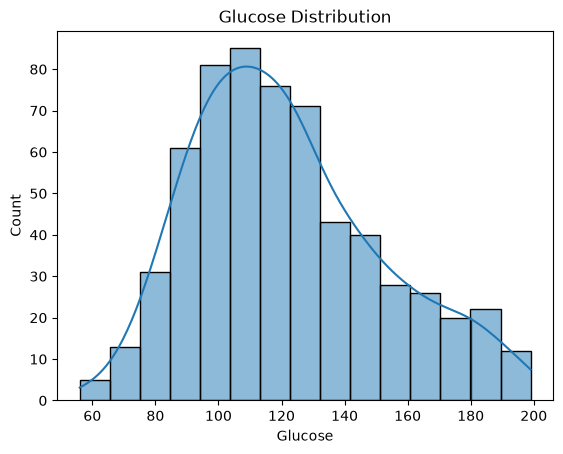

In [42]:
histo(X_train_, 'Glucose')

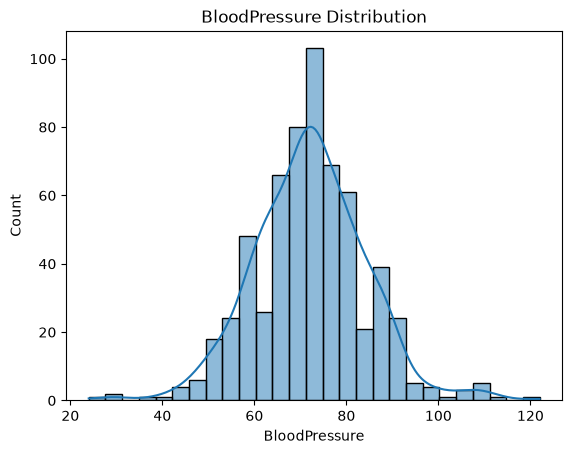

In [43]:
histo(X_train_, 'BloodPressure')

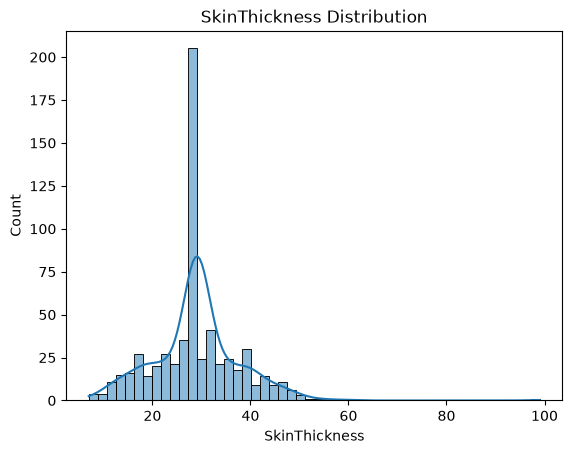

In [44]:
histo(X_train_, 'SkinThickness')

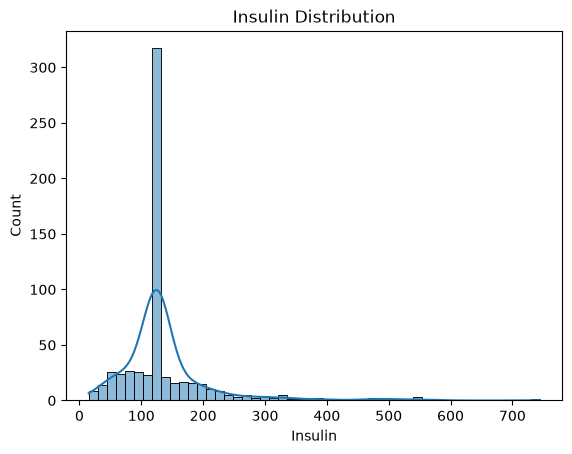

In [45]:
histo(X_train_, 'Insulin')

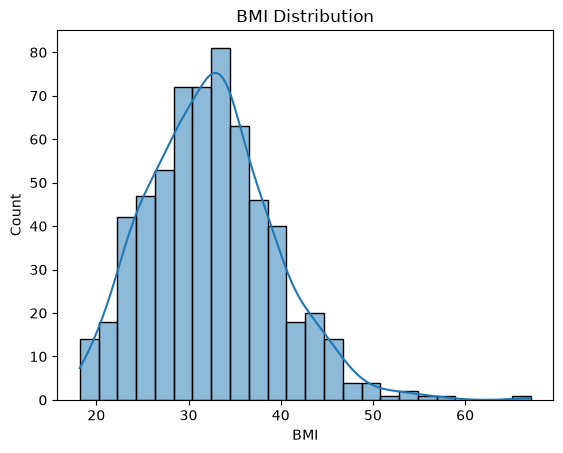

In [46]:
histo(X_train_, 'BMI')

In [47]:
X_train_.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,121.671010,72.140065,29.042345,137.705212,32.448208,0.477428,33.366450
std,3.314148,30.003794,12.275119,8.891855,78.764767,6.824122,0.330300,11.833438
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.625000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


Looking at Insulin, there is a need to investigate how far the outlier is from the data to know what type of scaling to perform

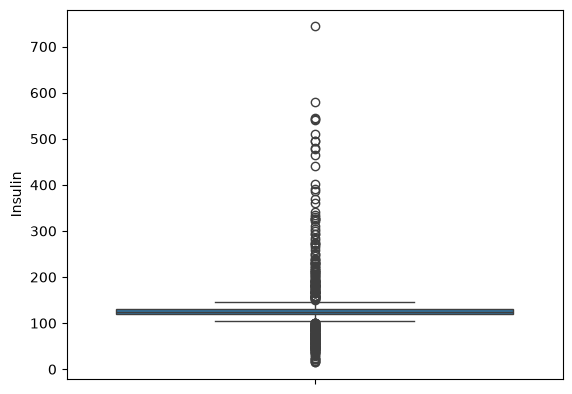

In [50]:
sns.boxplot(X_train_.Insulin);

The outliers are far away from the upper fence, so will be better to investigate using RobustScaler

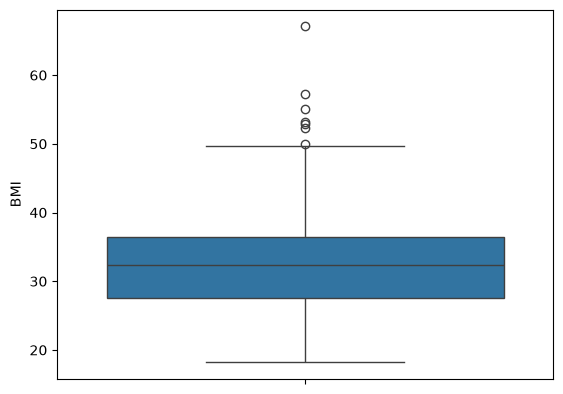

In [51]:
# Let's do the same analysis for BMI
sns.boxplot(X_train_.BMI);

The outliers do not appear to be too far from the upper fence. Considering investigating with StandardScaler

In [53]:
col = X_train_.columns.tolist()

In [56]:
col

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [61]:
X_train_filled

array([[1.00e+00, 9.00e+01, 6.20e+01, ..., 2.72e+01, 5.80e-01, 2.40e+01],
       [5.00e+00, 1.26e+02, 7.80e+01, ..., 2.96e+01, 4.39e-01, 4.00e+01],
       [2.00e+00, 1.05e+02, 5.80e+01, ..., 3.49e+01, 2.25e-01, 2.50e+01],
       ...,
       [1.00e+00, 9.70e+01, 7.00e+01, ..., 3.81e+01, 2.18e-01, 3.00e+01],
       [1.00e+01, 1.11e+02, 7.00e+01, ..., 2.75e+01, 1.41e-01, 4.00e+01],
       [4.00e+00, 1.44e+02, 5.80e+01, ..., 2.95e+01, 2.87e-01, 3.70e+01]],
      shape=(614, 8))

In [65]:
# Now let's consider Logistic Regression as Base model
# We have to scale the data

scaler_1 = StandardScaler()
scaler_2 = RobustScaler()

# Rebuild DataFrames with column names
X_train_scaled = pd.DataFrame(X_train_filled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_filled,  columns=X_test.columns,  index=X_test.index)

# scaler_1 on the other columns
X_train_scaled[col] = scaler_1.fit_transform(X_train_scaled[col])
X_test_scaled[col]  = scaler_1.transform(X_test_scaled[col])

# scaler_2 on Insulin (double brackets = 2D)
X_train_scaled[['Insulin']] = scaler_2.fit_transform(X_train_scaled[['Insulin']])
X_test_scaled[['Insulin']]  = scaler_2.transform(X_test_scaled[['Insulin']])

In [68]:
# Let's use the Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import cross_val_score

In [69]:
clf = LogisticRegression(class_weight='balanced')
clf.fit(X_train_scaled, y_train)
clf.score(X_test_scaled, y_test)

0.7337662337662337

In [86]:
def evaluation(model, X_test, y_test):
    y_preds = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    recall = recall_score(y_test, y_preds)
    precision = precision_score(y_test, y_preds)
    f1 = f1_score(y_test, y_preds)

    print(f'Accuracy: {accuracy * 100:.2f}%')
    print(f'Recall: {recall:.2f}')
    print(f'Precision: {precision:.2f}')
    print(f'F1: {f1:.2f}')

    return y_preds

In [87]:
y_preds = evaluation(clf, X_test_scaled, y_test)

Accuracy: 73.38%
Recall: 0.70
Precision: 0.60
F1: 0.65


In [88]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [89]:
confusion_matrix(y_test, y_preds)

array([[75, 25],
       [16, 38]])

In [83]:
cross_recall = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring='recall')
np.mean(cross_recall)

np.float64(0.7011074197120709)

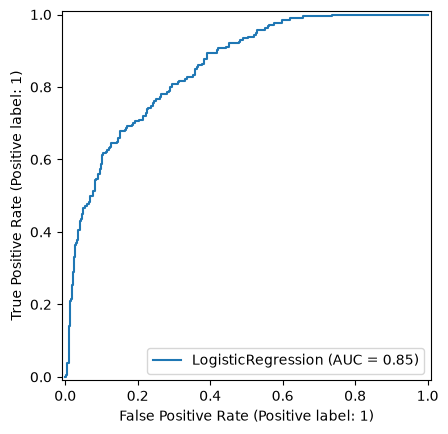

In [85]:
RocCurveDisplay.from_estimator(clf, X_train_scaled, y_train);